In [21]:
%pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
##IMPORTING THE CLEANED DATA
import pandas as pd
import numpy as np

data = pd.read_csv("LA_Assault_Data_2020_Present.csv")

In [3]:
##CONVERTING TO DATETIME
data["DATE OCC"] = pd.to_datetime(data["DATE OCC"])

In [4]:
##CREATING TIME VARIABLES
data["year"] = data["DATE OCC"].dt.year
data["month"] = data["DATE OCC"].dt.month
data["day_of_week"] = data["DATE OCC"].dt.dayofweek

In [5]:
##ESTABLISHING SPATIAL GRID CELLS

##0.01 degrees ≈ ~1km
grid_size = 0.01

data["lat_grid"] = (data["LAT"] // grid_size) * grid_size
data["lon_grid"] = (data["LON"] // grid_size) * grid_size

In [6]:
##CREATING A SPATIOTEMPORAL DATASET

crime_grid = (
    data.groupby(["lat_grid","lon_grid","year","month"])
    .size()
    .reset_index(name="crime_count")
)
##each row should represent a grid-cell and a time period

In [7]:
# Create full monthly time index
all_months = pd.date_range(
    start=data["DATE OCC"].min(),
    end=data["DATE OCC"].max(),
    freq="MS"
)

# Create full grid-time combinations
grid_index = pd.MultiIndex.from_product(
    [crime_grid["lat_grid"].unique(),
     crime_grid["lon_grid"].unique(),
     all_months],
    names=["lat_grid","lon_grid","date"]
)

full_grid = pd.DataFrame(index=grid_index).reset_index()

# Extract year/month
full_grid["year"] = full_grid["date"].dt.year
full_grid["month"] = full_grid["date"].dt.month

# Merge with crime counts
crime_grid = full_grid.merge(
    crime_grid,
    on=["lat_grid","lon_grid","year","month"],
    how="left"
)

# Fill missing crime counts
crime_grid["crime_count"] = crime_grid["crime_count"].fillna(0)

In [8]:
##ADDING LAG FEATURES
crime_grid = crime_grid.sort_values(["lat_grid", "lon_grid", "date"])

crime_grid["lag_1"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(1)
crime_grid["lag_3"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(3)
crime_grid["lag_6"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(6)

In [9]:
crime_grid = crime_grid.groupby(["lat_grid","lon_grid"]).filter(
    lambda x: x["crime_count"].sum() > 0
)

<h2>Random Forest Model 1</h2>
<p>One of the first models</p>

In [10]:
crime_grid = crime_grid.dropna(subset=["lag_1","lag_3","lag_6"])

In [11]:
train = crime_grid[crime_grid["year"] < 2022]
test = crime_grid[crime_grid["year"] >= 2022]

print(train.shape)
print(test.shape)

(21942, 9)
(47541, 9)


In [12]:
features = ["lat_grid", "lon_grid", "month", "lag_1", "lag_3", "lag_6"]

X_train = train[features]
y_train = train["crime_count"]

X_test = test[features]
y_test = test["crime_count"]

In [13]:
##Fitting Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [14]:
##Prediciting
pred_rf = rf_model.predict(X_test)

In [15]:
##Evaluating

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)


Random Forest MAE: 1.3725505641404536
Random Forest RMSE: 2.428970259122377


In [16]:
##Comparing To Baseline
mae = 1.0908197343812427
rmse = 2.3333593436303555

print("Baseline Regression MAE:", mae)
print("Baseline Regression RMSE:", rmse)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Baseline Regression MAE: 1.0908197343812427
Baseline Regression RMSE: 2.3333593436303555
Random Forest MAE: 1.3725505641404536
Random Forest RMSE: 2.428970259122377


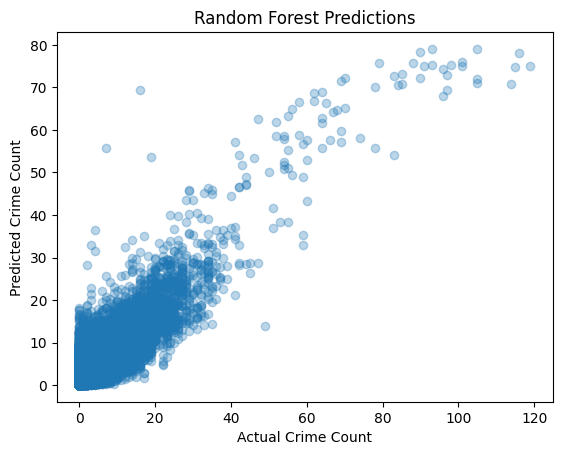

In [17]:
##Plotting Predicted vs Actual
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_rf, alpha=0.3)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Random Forest Predictions")
plt.show()

In [18]:
##Feature Importance
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
3,lag_1,0.674227
4,lag_3,0.157714
5,lag_6,0.085194
1,lon_grid,0.034834
0,lat_grid,0.024853
2,month,0.023178


<h3>Random Forest Model 2: Adding Rolling Features</h3>

In [19]:
# Sort first
crime_grid = crime_grid.sort_values(["lat_grid", "lon_grid", "date"]).copy()

# Group by grid cell
grouped = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"]

# Lag features if needed
crime_grid["lag_1"] = grouped.shift(1)
crime_grid["lag_3"] = grouped.shift(3)
crime_grid["lag_6"] = grouped.shift(6)

# Rolling features by grid cell
crime_grid["rolling_mean_3"] = grouped.transform(lambda x: x.shift(1).rolling(3).mean())
crime_grid["rolling_mean_6"] = grouped.transform(lambda x: x.shift(1).rolling(6).mean())
crime_grid["rolling_std_3"]  = grouped.transform(lambda x: x.shift(1).rolling(3).std())

In [20]:
crime_grid_model2 = crime_grid.dropna(subset=[
    "lag_1", "lag_3", "lag_6",
    "rolling_mean_3", "rolling_mean_6", "rolling_std_3"
]).copy()

In [21]:
features_v2 = [
    "lat_grid", "lon_grid", "month", "year",
    "lag_1", "lag_3", "lag_6",
    "rolling_mean_3", "rolling_mean_6", "rolling_std_3"
]

In [22]:
# make sure date is datetime
crime_grid_model2["date"] = pd.to_datetime(crime_grid_model2["date"])

# time-aware split
train = crime_grid_model2[crime_grid_model2["date"] < "2022-01-01"].copy()
test = crime_grid_model2[crime_grid_model2["date"] >= "2022-01-01"].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train min/max:", train["date"].min(), train["date"].max())
print("Test min/max:", test["date"].min(), test["date"].max())

Train shape: (14628, 12)
Test shape: (47541, 12)
Train min/max: 2021-01-01 00:00:00 2021-12-01 00:00:00
Test min/max: 2022-01-01 00:00:00 2025-03-01 00:00:00


In [23]:
X_train = train[features_v2]
X_test = test[features_v2]
y_train = train["crime_count"]
y_test = test["crime_count"]

rf_model_v2.fit(X_train, y_train)
pred_rf_v2 = rf_model_v2.predict(X_test)

NameError: name 'rf_model_v2' is not defined

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model_v2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model_v2.fit(X_train, y_train)
pred_rf_v2 = rf_model_v2.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf_v2 = mean_absolute_error(y_test, pred_rf_v2)
rmse_rf_v2 = np.sqrt(mean_squared_error(y_test, pred_rf_v2))

print("Random Forest V2 MAE:", mae_rf_v2)
print("Random Forest V2 RMSE:", rmse_rf_v2)

Random Forest V2 MAE: 1.342399878090182
Random Forest V2 RMSE: 2.468676272744084


In [26]:
###COMPARISON
comparison = pd.DataFrame({
    "Model": ["Baseline Regression", "Random Forest V1", "Random Forest V2"],
    "MAE": [mae, mae_rf, mae_rf_v2],
    "RMSE": [rmse, rmse_rf, rmse_rf_v2]
})

comparison

,Model,MAE,RMSE
0,Baseline Regression,1.090820,2.333359
1,Random Forest V1,1.372551,2.428970
2,Random Forest V2,1.342400,2.468676


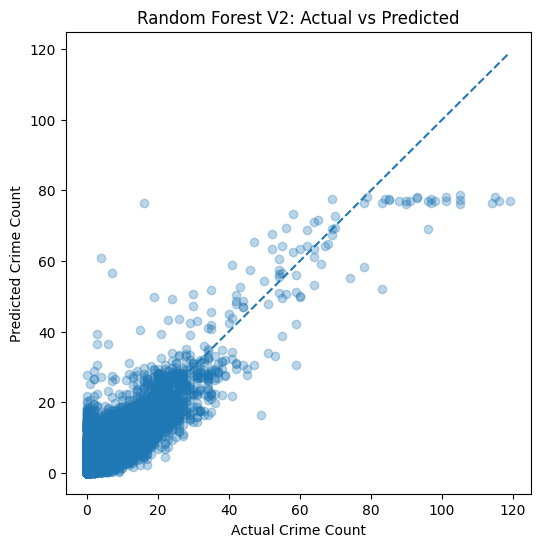

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf_v2, alpha=0.3)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Random Forest V2: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.show()

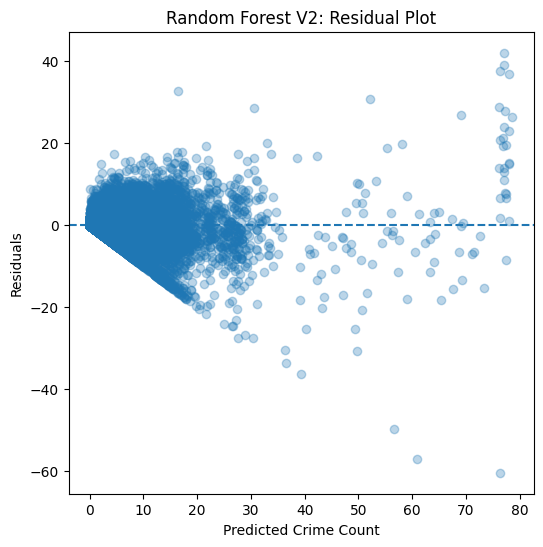

In [28]:
residuals_v2 = y_test - pred_rf_v2

plt.figure(figsize=(6,6))
plt.scatter(pred_rf_v2, residuals_v2, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Crime Count")
plt.ylabel("Residuals")
plt.title("Random Forest V2: Residual Plot")
plt.show()

In our random forest v2 we added rolling features. Due to the limit of time within our data set, rolling windows like 3 and 6 months, may smooth too much and overlap heavily with the lag features. We also dropped a good bit of data dropping the NANs.

<h3>Random Forest Model 3: Tuning the Model</h3>

In [29]:
rf_model_v3 = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model_v3.fit(X_train, y_train)
pred_rf_v3 = rf_model_v3.predict(X_test)

mae_rf_v3 = mean_absolute_error(y_test, pred_rf_v3)
rmse_rf_v3 = np.sqrt(mean_squared_error(y_test, pred_rf_v3))

print("Random Forest V3 MAE:", mae_rf_v3)
print("Random Forest V3 RMSE:", rmse_rf_v3)

Random Forest V3 MAE: 1.3622460493785893
Random Forest V3 RMSE: 2.4827850907984224


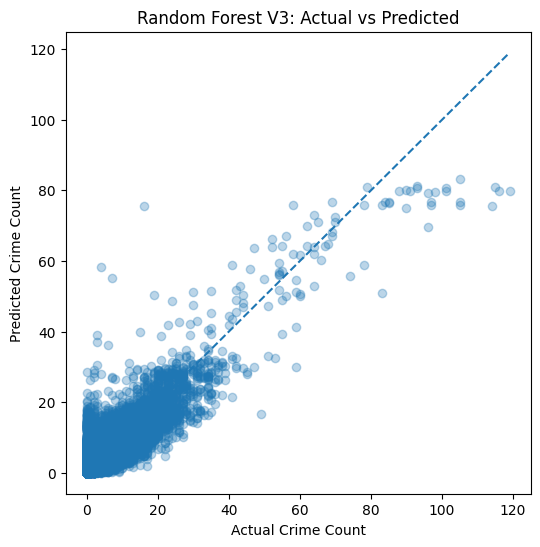

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf_v3, alpha=0.3)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Random Forest V3: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.show()

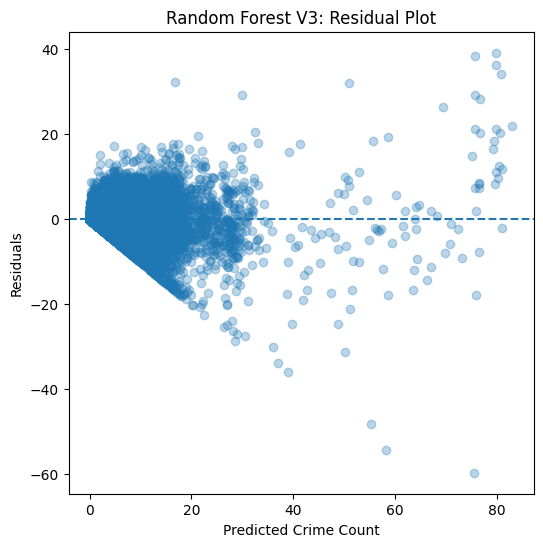

In [31]:
residuals_v3 = y_test - pred_rf_v3

plt.figure(figsize=(6,6))
plt.scatter(pred_rf_v3, residuals_v3, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Crime Count")
plt.ylabel("Residuals")
plt.title("Random Forest V3: Residual Plot")
plt.show()

A baseline linear regression model was first developed to provide an interpretable benchmark. A Random Forest model was then introduced to capture nonlinear relationships and interactions between temporal and spatial features. This model significantly improved RMSE compared to the baseline.

Additional feature engineering using rolling statistics and further hyperparameter tuning were explored; however, these modifications did not improve model performance. This suggests that lag-based features were sufficient to capture temporal dependencies, and that additional complexity introduced noise and reduced generalization.

As a result, the initial Random Forest model (V1) was selected as the final model due to its balance of performance, stability, and interpretability.

In [37]:
import xgboost as xgb

# 1. Prepare the data (Using your existing feature list from V1)
features = ["lat_grid", "lon_grid", "month", "lag_1", "lag_3", "lag_6"]
X_train = train[features]
y_train = train["crime_count"]
X_test = test[features]
y_test = test["crime_count"]

# 2. Initialize XGBoost Regressor
# We use 'count:poisson' because we are predicting discrete crime counts
xgb_model = xgb.XGBRegressor(
    objective='count:poisson',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 3. Fit the model
xgb_model.fit(X_train, y_train)

# 4. Make Predictions
pred_xgb = xgb_model.predict(X_test)

# 5. Evaluate
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print(f"XGBoost MAE: {mae_xgb:.4f}")
print(f"XGBoost RMSE: {rmse_xgb:.4f}")

# 6. Compare Feature Importance
import pandas as pd
xgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nXGBoost Feature Importance:")
print(xgb_importance)

XGBoost MAE: 1.3508
XGBoost RMSE: 2.3951

XGBoost Feature Importance:
    Feature  Importance
3     lag_1    0.469519
4     lag_3    0.280602
5     lag_6    0.180048
1  lon_grid    0.025186
0  lat_grid    0.024938
2     month    0.019707


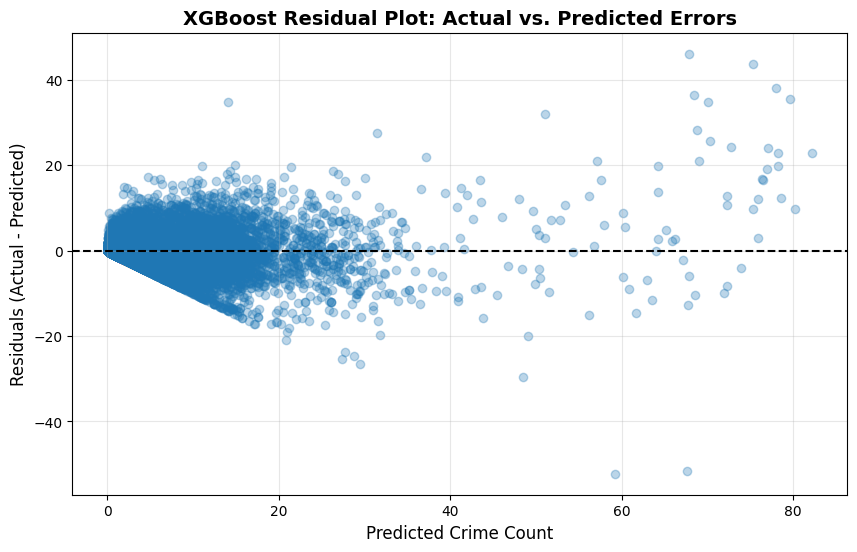

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Residuals
residuals_xgb = y_test - pred_xgb

# 2. Create the Plot
plt.figure(figsize=(10, 6))
plt.scatter(pred_xgb, residuals_xgb, alpha=0.3)

# Add a horizontal line at 0 to show the "perfect prediction" baseline
plt.axhline(y=0, color='black', linestyle='--')

plt.title("XGBoost Residual Plot: Actual vs. Predicted Errors", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Crime Count", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()